# Data Preprocessing
## Dataset: Hotel Bookings
---

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import sklearn.preprocessing
import warnings
warnings.filterwarnings("ignore")

## 2. Load Dataset

In [2]:
try:
    df = pd.read_csv("../data/raw/hotel_bookings.csv")
    print("Dataset loaded successfully.")
    print(f"Shape awal: {df.shape}")
except FileNotFoundError:
    print("File not found. Please check the file path.")

Dataset loaded successfully.
Shape awal: (119390, 32)


## 3. Hapus Kolom Tidak Relevan

Berdasarkan EDA, kolom `company` memiliki **94.31%** missing value sehingga tidak layak dipertahankan.
Kolom `reservation_status_date` juga dihapus karena merupakan atribut administratif yang tidak informatif untuk analisis.

In [3]:
cols_to_drop = ['company', 'reservation_status_date']
df.drop(columns=cols_to_drop, inplace=True)

print("Kolom yang dihapus:", cols_to_drop)
print(f"Shape setelah hapus kolom: {df.shape}")

Kolom yang dihapus: ['company', 'reservation_status_date']
Shape setelah hapus kolom: (119390, 30)


## 4. Hapus Duplikat

Dari EDA ditemukan **31.994 baris duplikat (26.80%)**. Semua baris duplikat dihapus untuk menjaga integritas data.

In [4]:
sebelum = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
sesudah = len(df)

print(f"Jumlah baris sebelum  : {sebelum:,}")
print(f"Jumlah duplikat dihapus: {sebelum - sesudah:,}")
print(f"Jumlah baris sesudah  : {sesudah:,}")

Jumlah baris sebelum  : 119,390
Jumlah duplikat dihapus: 32,247
Jumlah baris sesudah  : 87,143


## 5. Visualisasi Sebelum vs Sesudah Penghapusan Duplikat

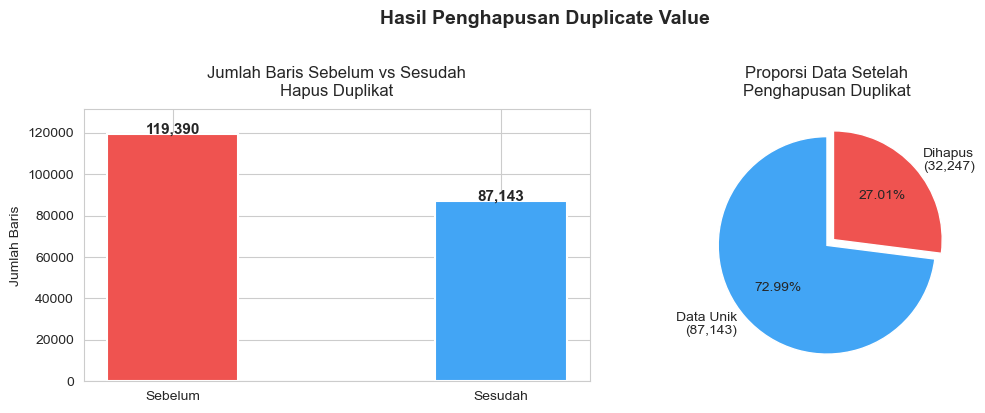

In [5]:
sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

labels = ['Sebelum', 'Sesudah']
values = [sebelum, sesudah]
colors = ['#EF5350', '#42A5F5']

bars = axes[0].bar(labels, values, color=colors, width=0.4, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{val:,}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Jumlah Baris Sebelum vs Sesudah\nHapus Duplikat', fontsize=12, pad=10)
axes[0].set_ylabel('Jumlah Baris')
axes[0].set_ylim(0, sebelum * 1.1)

sizes = [sesudah, sebelum - sesudah]
pie_labels = [f'Data Unik\n({sesudah:,})', f'Dihapus\n({sebelum - sesudah:,})']
axes[1].pie(sizes, labels=pie_labels, autopct='%1.2f%%',
            colors=['#42A5F5', '#EF5350'], startangle=90,
            explode=[0, 0.08], textprops={'fontsize': 10})
axes[1].set_title('Proporsi Data Setelah\nPenghapusan Duplikat', fontsize=12, pad=10)

plt.suptitle('Hasil Penghapusan Duplicate Value', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Penanganan Missing Value

Setiap kolom yang masih memiliki missing value ditangani dengan strategi berbeda:
- `children` → isi dengan **0** (asumsi tidak ada anak jika tidak disebutkan)
- `agent` → isi dengan **0** (asumsi pemesanan langsung tanpa agen)
- `country` → isi dengan **modus** (negara paling umum)

In [6]:
print("Missing value sebelum penanganan:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# children: isi 0
df['children'] = df['children'].fillna(0).astype(int)

# agent: isi 0 (tanpa agen)
df['agent'] = df['agent'].fillna(0).astype(int)

# country: isi modus
modus_country = df['country'].mode()[0]
df['country'] = df['country'].fillna(modus_country)

print("\nMissing value sesudah penanganan:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nTidak ada missing value tersisa." if df.isnull().sum().sum() == 0 else "⚠ Masih ada missing value.")

Missing value sebelum penanganan:
children        4
country       451
agent       12159
dtype: int64

Missing value sesudah penanganan:
Series([], dtype: int64)

Tidak ada missing value tersisa.


## 7. Visualisasi Missing Value Sebelum vs Sesudah Penanganan

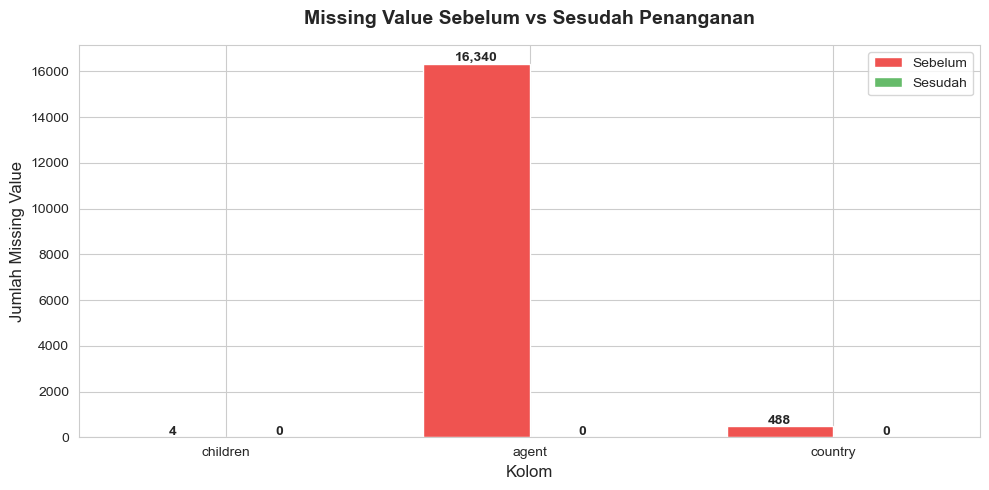

In [7]:
missing_cols = ['children', 'agent', 'country']
before_vals  = [4, 16340, 488]
after_vals   = [df[c].isnull().sum() for c in missing_cols]

x = np.arange(len(missing_cols))
width = 0.35

sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(x - width/2, before_vals, width, label='Sebelum', color='#EF5350', edgecolor='white')
bars2 = ax.bar(x + width/2, after_vals,  width, label='Sesudah', color='#66BB6A', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{int(bar.get_height()):,}', ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{int(bar.get_height())}', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Missing Value Sebelum vs Sesudah Penanganan', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Kolom', fontsize=12)
ax.set_ylabel('Jumlah Missing Value', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(missing_cols)
ax.legend()
plt.tight_layout()
plt.show()

## 8. Penanganan Inconsistent Value

Dari EDA ditemukan nilai `Undefined` pada kolom `meal` dan `market_segment`.
Nilai `Undefined` pada `meal` diganti dengan `SC` (Self Catering / tanpa paket makan).
Nilai `Undefined` pada `market_segment` diganti dengan `Direct`.

In [8]:
print("Nilai unik meal sebelum:", df['meal'].unique())
print("Nilai unik market_segment sebelum:", df['market_segment'].unique())

df['meal'] = df['meal'].replace('Undefined', 'SC')
df['market_segment'] = df['market_segment'].replace('Undefined', 'Direct')

print("\nNilai unik meal sesudah:", df['meal'].unique())
print("Nilai unik market_segment sesudah:", df['market_segment'].unique())

Nilai unik meal sebelum: <ArrowStringArray>
['BB', 'FB', 'HB', 'SC', 'Undefined']
Length: 5, dtype: str
Nilai unik market_segment sebelum: <ArrowStringArray>
[       'Direct',     'Corporate',     'Online TA', 'Offline TA/TO',
 'Complementary',        'Groups',     'Undefined',      'Aviation']
Length: 8, dtype: str

Nilai unik meal sesudah: <ArrowStringArray>
['BB', 'FB', 'HB', 'SC']
Length: 4, dtype: str
Nilai unik market_segment sesudah: <ArrowStringArray>
[       'Direct',     'Corporate',     'Online TA', 'Offline TA/TO',
 'Complementary',        'Groups',      'Aviation']
Length: 7, dtype: str


## 9. Visualisasi Distribusi Meal dan Market Segment Sesudah Penanganan

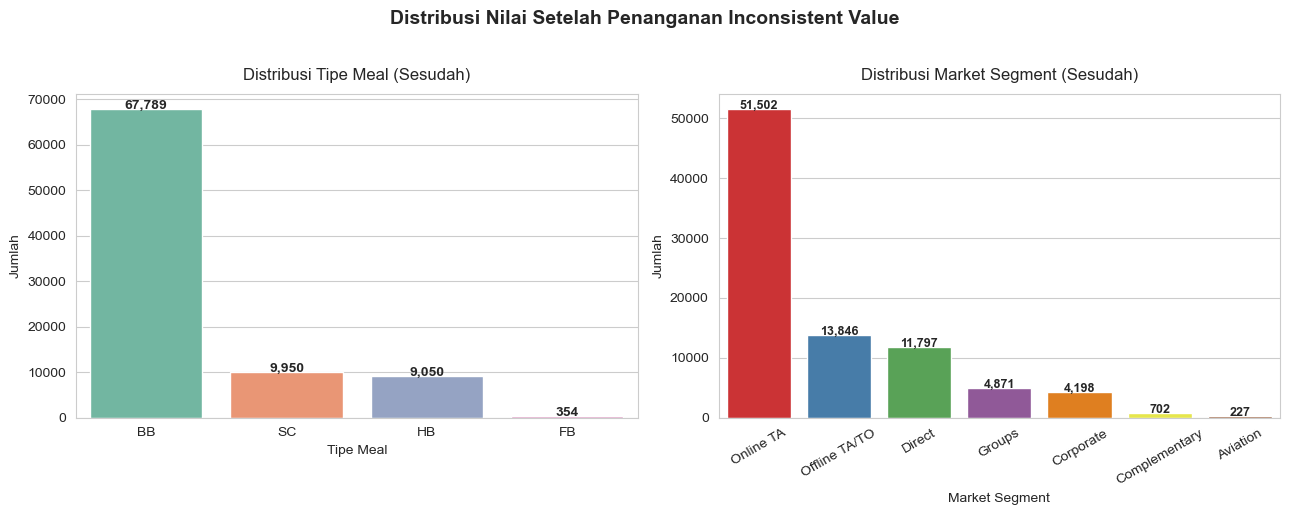

In [9]:
sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Meal
meal_counts = df['meal'].value_counts().reset_index()
meal_counts.columns = ['Meal', 'Jumlah']
bars = sns.barplot(data=meal_counts, x='Meal', y='Jumlah', palette='Set2', ax=axes[0])
for bar, val in zip(bars.patches, meal_counts['Jumlah']):
    bars.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
              f'{val:,}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Distribusi Tipe Meal (Sesudah)', fontsize=12, pad=10)
axes[0].set_xlabel('Tipe Meal')
axes[0].set_ylabel('Jumlah')

# Market Segment
seg_counts = df['market_segment'].value_counts().reset_index()
seg_counts.columns = ['Segment', 'Jumlah']
bars2 = sns.barplot(data=seg_counts, x='Segment', y='Jumlah', palette='Set1', ax=axes[1])
for bar, val in zip(bars2.patches, seg_counts['Jumlah']):
    bars2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
               f'{val:,}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Distribusi Market Segment (Sesudah)', fontsize=12, pad=10)
axes[1].set_xlabel('Market Segment')
axes[1].set_ylabel('Jumlah')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Distribusi Nilai Setelah Penanganan Inconsistent Value',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. Penanganan Outlier pada Kolom `adr`

Dari EDA, kolom `adr` (Average Daily Rate) memiliki nilai maksimum ekstrem (€5.400) dan ada nilai negatif yang tidak wajar.
Outlier ditangani menggunakan metode **IQR (Interquartile Range)**.

In [10]:
print(f"ADR sebelum - Min: {df['adr'].min():.2f}, Max: {df['adr'].max():.2f}, Mean: {df['adr'].mean():.2f}")
print(f"Jumlah ADR negatif: {(df['adr'] < 0).sum()}")

Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)
IQR = Q3 - Q1
batas_bawah = Q1 - 1.5 * IQR
batas_atas  = Q3 + 1.5 * IQR

outlier_adr = ((df['adr'] < batas_bawah) | (df['adr'] > batas_atas)).sum()
df = df[(df['adr'] >= batas_bawah) & (df['adr'] <= batas_atas)]
df.reset_index(drop=True, inplace=True)

print(f"\nQ1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"Batas bawah: {batas_bawah:.2f} | Batas atas: {batas_atas:.2f}")
print(f"Jumlah outlier dihapus: {outlier_adr:,}")
print(f"ADR sesudah - Min: {df['adr'].min():.2f}, Max: {df['adr'].max():.2f}, Mean: {df['adr'].mean():.2f}")
print(f"Shape setelah hapus outlier ADR: {df.shape}")

ADR sebelum - Min: -6.38, Max: 5400.00, Mean: 106.36
Jumlah ADR negatif: 1

Q1=72.00, Q3=134.00, IQR=62.00
Batas bawah: -21.00 | Batas atas: 227.00
Jumlah outlier dihapus: 2,485
ADR sesudah - Min: -6.38, Max: 227.00, Mean: 101.80
Shape setelah hapus outlier ADR: (84658, 30)


## 11. Visualisasi Distribusi ADR Sebelum vs Sesudah Penanganan Outlier

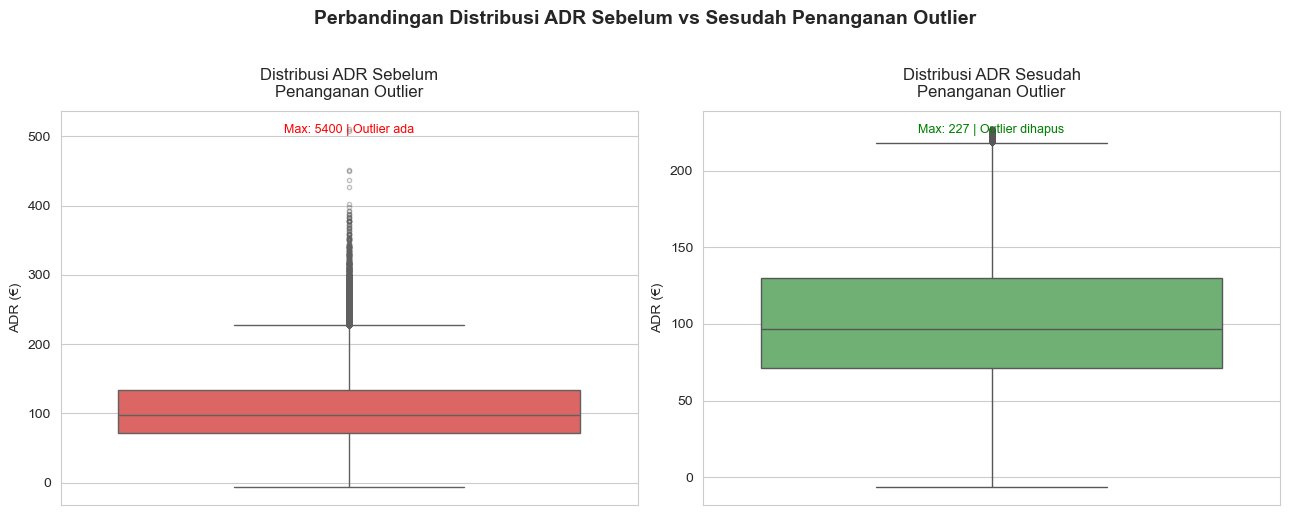

In [11]:
df_raw_adr = pd.read_csv("../data/raw/hotel_bookings.csv")
df_raw_adr.drop_duplicates(inplace=True)

sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sebelum (filtered for display, not for removal)
sns.boxplot(y=df_raw_adr['adr'][df_raw_adr['adr'] < 600],
            ax=axes[0], color='#EF5350', flierprops=dict(marker='o', markersize=3, alpha=0.4))
axes[0].set_title('Distribusi ADR Sebelum\nPenanganan Outlier', fontsize=12, pad=10)
axes[0].set_ylabel('ADR (€)')
axes[0].text(0.5, 0.97, f"Max: {df_raw_adr['adr'].max():.0f} | Outlier ada",
             ha='center', va='top', transform=axes[0].transAxes, fontsize=9, color='red')

# Sesudah
sns.boxplot(y=df['adr'], ax=axes[1], color='#66BB6A',
            flierprops=dict(marker='o', markersize=3, alpha=0.4))
axes[1].set_title('Distribusi ADR Sesudah\nPenanganan Outlier', fontsize=12, pad=10)
axes[1].set_ylabel('ADR (€)')
axes[1].text(0.5, 0.97, f"Max: {df['adr'].max():.0f} | Outlier dihapus",
             ha='center', va='top', transform=axes[1].transAxes, fontsize=9, color='green')

plt.suptitle('Perbandingan Distribusi ADR Sebelum vs Sesudah Penanganan Outlier',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 12. Penanganan Outlier pada Kolom `lead_time`

Dari EDA, `lead_time` memiliki distribusi *right-skewed* dengan nilai maksimum 737 hari.
Outlier ditangani menggunakan metode **IQR**.

In [12]:
print(f"Lead time sebelum - Min: {df['lead_time'].min()}, Max: {df['lead_time'].max()}, Mean: {df['lead_time'].mean():.2f}")

Q1_lt = df['lead_time'].quantile(0.25)
Q3_lt = df['lead_time'].quantile(0.75)
IQR_lt = Q3_lt - Q1_lt
batas_bawah_lt = Q1_lt - 1.5 * IQR_lt
batas_atas_lt  = Q3_lt + 1.5 * IQR_lt

outlier_lt = ((df['lead_time'] < batas_bawah_lt) | (df['lead_time'] > batas_atas_lt)).sum()
df = df[(df['lead_time'] >= batas_bawah_lt) & (df['lead_time'] <= batas_atas_lt)]
df.reset_index(drop=True, inplace=True)

print(f"Q1={Q1_lt:.0f}, Q3={Q3_lt:.0f}, IQR={IQR_lt:.0f}")
print(f"Batas bawah: {batas_bawah_lt:.0f} | Batas atas: {batas_atas_lt:.0f}")
print(f"Jumlah outlier dihapus: {outlier_lt:,}")
print(f"Lead time sesudah - Min: {df['lead_time'].min()}, Max: {df['lead_time'].max()}, Mean: {df['lead_time'].mean():.2f}")
print(f"Shape setelah hapus outlier lead_time: {df.shape}")

Lead time sebelum - Min: 0, Max: 737, Mean: 79.97
Q1=11, Q3=125, IQR=114
Batas bawah: -160 | Batas atas: 296
Jumlah outlier dihapus: 2,336
Lead time sesudah - Min: 0, Max: 296, Mean: 72.25
Shape setelah hapus outlier lead_time: (82322, 30)


## 13. Visualisasi Distribusi Lead Time Sebelum vs Sesudah Penanganan Outlier

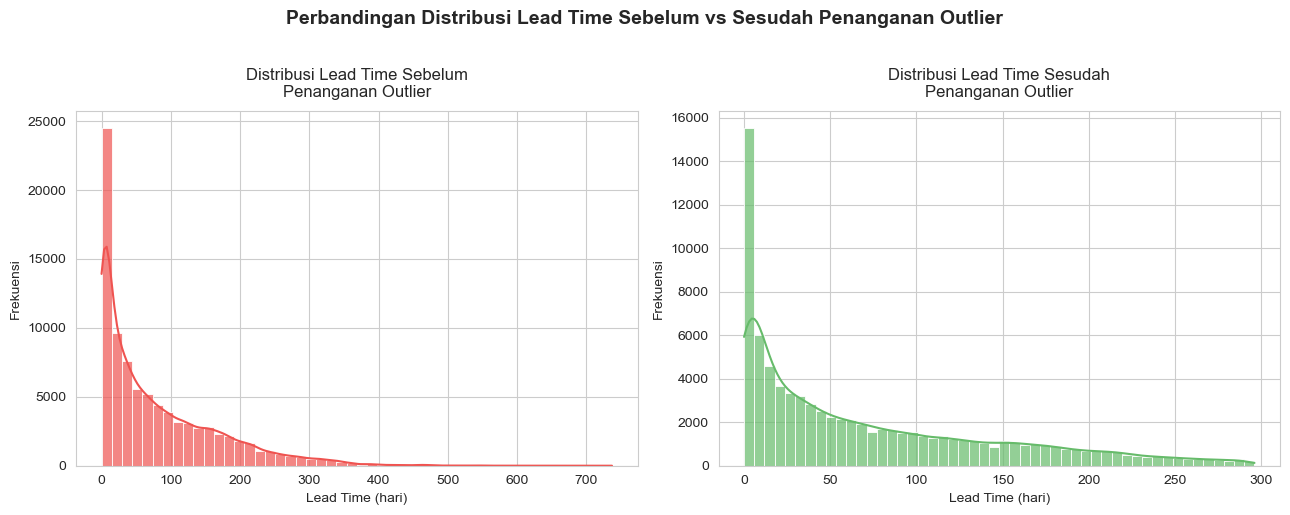

In [13]:
df_raw_lt = pd.read_csv("../data/raw/hotel_bookings.csv")
df_raw_lt.drop_duplicates(inplace=True)

sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df_raw_lt['lead_time'], bins=50, kde=True, color='#EF5350', ax=axes[0], alpha=0.7)
axes[0].set_title('Distribusi Lead Time Sebelum\nPenanganan Outlier', fontsize=12, pad=10)
axes[0].set_xlabel('Lead Time (hari)')
axes[0].set_ylabel('Frekuensi')

sns.histplot(df['lead_time'], bins=50, kde=True, color='#66BB6A', ax=axes[1], alpha=0.7)
axes[1].set_title('Distribusi Lead Time Sesudah\nPenanganan Outlier', fontsize=12, pad=10)
axes[1].set_xlabel('Lead Time (hari)')
axes[1].set_ylabel('Frekuensi')

plt.suptitle('Perbandingan Distribusi Lead Time Sebelum vs Sesudah Penanganan Outlier',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 14. Feature Engineering

Menambahkan kolom baru yang informatif untuk analisis lanjutan:
- `total_guests` → total tamu (adults + children + babies)
- `total_stays` → total malam menginap (weekend + weeknight)
- `revenue` → estimasi pendapatan (adr × total_stays)
- `arrival_season` → musim kedatangan berdasarkan bulan

In [14]:
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df['total_stays']  = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['revenue']      = df['adr'] * df['total_stays']

season_map = {
    'December': 'Winter', 'January': 'Winter', 'February': 'Winter',
    'March': 'Spring',    'April': 'Spring',   'May': 'Spring',
    'June': 'Summer',     'July': 'Summer',    'August': 'Summer',
    'September': 'Fall',  'October': 'Fall',   'November': 'Fall'
}
df['arrival_season'] = df['arrival_date_month'].map(season_map)

print("Fitur baru yang ditambahkan:")
print(df[['total_guests', 'total_stays', 'revenue', 'arrival_season']].head(10))
print(f"\nShape sesudah feature engineering: {df.shape}")

Fitur baru yang ditambahkan:
   total_guests  total_stays  revenue arrival_season
0             1            1     75.0         Summer
1             1            1     75.0         Summer
2             2            2    196.0         Summer
3             2            2    214.0         Summer
4             2            2    206.0         Summer
5             2            3    246.0         Summer
6             2            3    316.5         Summer
7             2            4    492.0         Summer
8             2            4    580.0         Summer
9             2            4    388.0         Summer

Shape sesudah feature engineering: (82322, 34)


## 15. Visualisasi Fitur Baru Hasil Feature Engineering

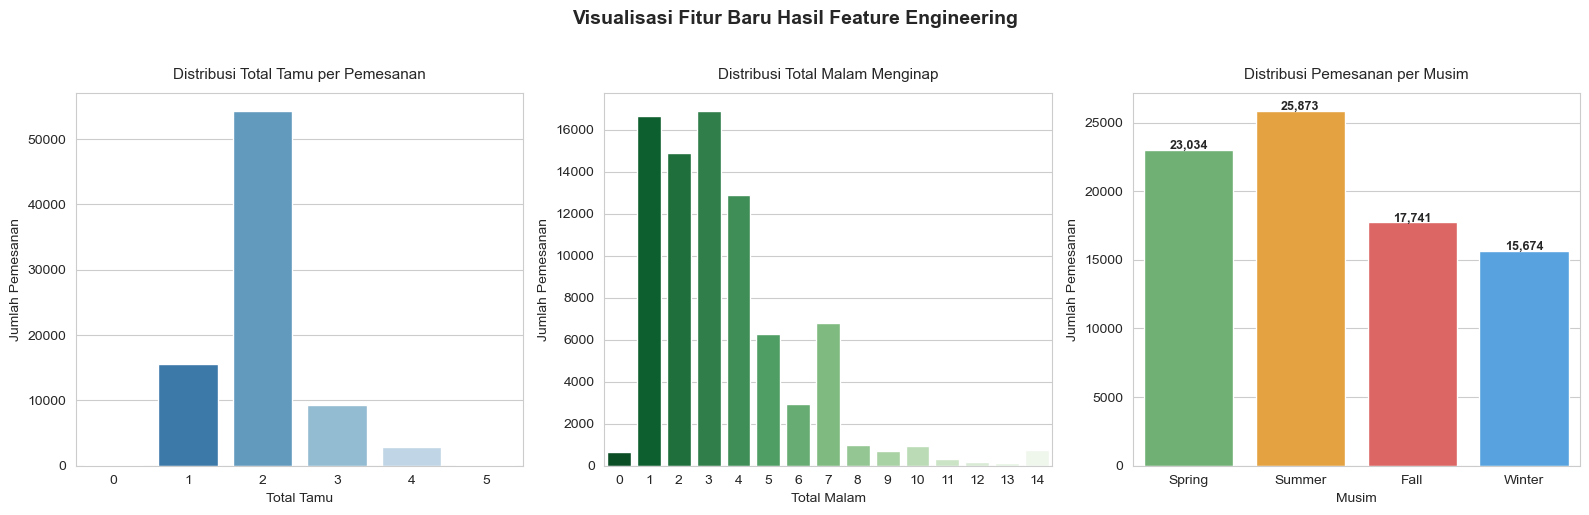

In [15]:
sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Total Guests
guest_counts = df['total_guests'].value_counts().sort_index().reset_index()
guest_counts.columns = ['Total Tamu', 'Jumlah']
guest_counts = guest_counts[guest_counts['Total Tamu'] <= 6]
sns.barplot(data=guest_counts, x='Total Tamu', y='Jumlah', palette='Blues_r', ax=axes[0])
axes[0].set_title('Distribusi Total Tamu per Pemesanan', fontsize=11, pad=10)
axes[0].set_xlabel('Total Tamu')
axes[0].set_ylabel('Jumlah Pemesanan')

# Total Stays
stays_counts = df['total_stays'].value_counts().sort_index().reset_index()
stays_counts.columns = ['Total Malam', 'Jumlah']
stays_counts = stays_counts[stays_counts['Total Malam'] <= 14]
sns.barplot(data=stays_counts, x='Total Malam', y='Jumlah', palette='Greens_r', ax=axes[1])
axes[1].set_title('Distribusi Total Malam Menginap', fontsize=11, pad=10)
axes[1].set_xlabel('Total Malam')
axes[1].set_ylabel('Jumlah Pemesanan')

# Arrival Season
season_counts = df['arrival_season'].value_counts().reset_index()
season_counts.columns = ['Musim', 'Jumlah']
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_counts['Musim'] = pd.Categorical(season_counts['Musim'], categories=season_order, ordered=True)
season_counts = season_counts.sort_values('Musim')
palette_season = {'Spring': '#66BB6A', 'Summer': '#FFA726', 'Fall': '#EF5350', 'Winter': '#42A5F5'}
sns.barplot(data=season_counts, x='Musim', y='Jumlah',
            palette=[palette_season[s] for s in season_counts['Musim']], ax=axes[2])
for bar, val in zip(axes[2].patches, season_counts['Jumlah']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', fontsize=9, fontweight='bold')
axes[2].set_title('Distribusi Pemesanan per Musim', fontsize=11, pad=10)
axes[2].set_xlabel('Musim')
axes[2].set_ylabel('Jumlah Pemesanan')

plt.suptitle('Visualisasi Fitur Baru Hasil Feature Engineering',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 16. Encoding Variabel Kategorikal

Variabel kategorikal dikonversi menjadi numerik menggunakan:
- **Label Encoding** → untuk kolom biner atau ordinal (`hotel`, `is_canceled` sudah numerik)
- **One-Hot Encoding** → untuk kolom nominal dengan beberapa kategori (`meal`, `market_segment`, `customer_type`, `deposit_type`, `arrival_season`)

In [16]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

# Label Encoding: hotel (binary)
le = LabelEncoder()
df_encoded['hotel_enc'] = le.fit_transform(df_encoded['hotel'])
print("Hotel encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

# One-Hot Encoding
ohe_cols = ['meal', 'market_segment', 'customer_type', 'deposit_type', 'arrival_season']
df_encoded = pd.get_dummies(df_encoded, columns=ohe_cols, prefix=ohe_cols)

print(f"\nShape sebelum encoding : {df.shape}")
print(f"Shape sesudah encoding  : {df_encoded.shape}")
print(f"\nKolom baru hasil OHE:")
new_cols = [c for c in df_encoded.columns if any(c.startswith(p+'_') for p in ohe_cols)]
print(new_cols)

Hotel encoding: {'City Hotel': np.int64(0), 'Resort Hotel': np.int64(1)}

Shape sebelum encoding : (82322, 34)
Shape sesudah encoding  : (82322, 52)

Kolom baru hasil OHE:
['meal_BB', 'meal_FB', 'meal_HB', 'meal_SC', 'market_segment_Aviation', 'market_segment_Complementary', 'market_segment_Corporate', 'market_segment_Direct', 'market_segment_Groups', 'market_segment_Offline TA/TO', 'market_segment_Online TA', 'customer_type_Contract', 'customer_type_Group', 'customer_type_Transient', 'customer_type_Transient-Party', 'deposit_type_No Deposit', 'deposit_type_Non Refund', 'deposit_type_Refundable', 'arrival_season_Fall', 'arrival_season_Spring', 'arrival_season_Summer', 'arrival_season_Winter']


## 17. Visualisasi Distribusi Kolom Hasil Encoding

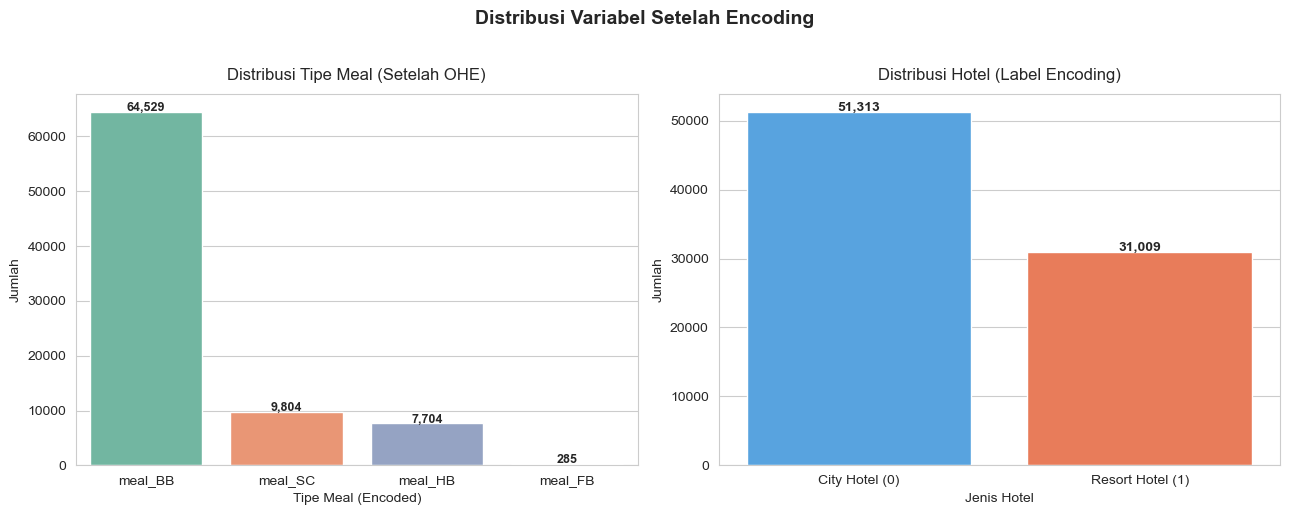

In [17]:
sns.set_style('whitegrid')

# Tampilkan distribusi meal encoding sebagai contoh
meal_cols = [c for c in df_encoded.columns if c.startswith('meal_')]
meal_sums = df_encoded[meal_cols].sum().sort_values(ascending=False).reset_index()
meal_sums.columns = ['Meal Type', 'Jumlah']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = sns.barplot(data=meal_sums, x='Meal Type', y='Jumlah', palette='Set2', ax=axes[0])
for bar, val in zip(bars.patches, meal_sums['Jumlah']):
    bars.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
              f'{int(val):,}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Distribusi Tipe Meal (Setelah OHE)', fontsize=12, pad=10)
axes[0].set_xlabel('Tipe Meal (Encoded)')
axes[0].set_ylabel('Jumlah')

# Hotel encoding
hotel_enc_counts = df_encoded['hotel_enc'].value_counts().reset_index()
hotel_enc_counts.columns = ['hotel_enc', 'Jumlah']
hotel_enc_counts['Label'] = hotel_enc_counts['hotel_enc'].map({0: 'City Hotel (0)', 1: 'Resort Hotel (1)'})
bars2 = sns.barplot(data=hotel_enc_counts, x='Label', y='Jumlah',
                    palette=['#42A5F5', '#FF7043'], ax=axes[1])
for bar, val in zip(bars2.patches, hotel_enc_counts['Jumlah']):
    bars2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
               f'{int(val):,}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Distribusi Hotel (Label Encoding)', fontsize=12, pad=10)
axes[1].set_xlabel('Jenis Hotel')
axes[1].set_ylabel('Jumlah')

plt.suptitle('Distribusi Variabel Setelah Encoding', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 18. Normalisasi Fitur Numerik

Fitur numerik dinormalisasi menggunakan **Min-Max Scaling** agar semua nilai berada di rentang [0, 1].
Ini penting untuk algoritma yang sensitif terhadap skala fitur.

In [18]:
from sklearn.preprocessing import MinMaxScaler

cols_to_scale = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
                 'adults', 'children', 'babies', 'previous_cancellations',
                 'booking_changes', 'days_in_waiting_list', 'adr',
                 'total_guests', 'total_stays', 'revenue']

scaler = MinMaxScaler()
df_scaled = df_encoded.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df_scaled[cols_to_scale])

print("Statistik setelah normalisasi (kolom terpilih):")
print(df_scaled[cols_to_scale].describe().round(4).T[['min', 'max', 'mean', 'std']])

Statistik setelah normalisasi (kolom terpilih):
                         min  max    mean     std
lead_time                0.0  1.0  0.2441  0.2486
stays_in_weekend_nights  0.0  1.0  0.0522  0.0538
stays_in_week_nights     0.0  1.0  0.0516  0.0406
adults                   0.0  1.0  0.4655  0.1274
children                 0.0  1.0  0.0118  0.0417
babies                   0.0  1.0  0.0011  0.0113
previous_cancellations   0.0  1.0  0.0012  0.0145
booking_changes          0.0  1.0  0.0126  0.0340
days_in_waiting_list     0.0  1.0  0.0023  0.0307
adr                      0.0  1.0  0.4647  0.1944
total_guests             0.0  1.0  0.1659  0.0564
total_stays              0.0  1.0  0.0518  0.0395
revenue                  0.0  1.0  0.0568  0.0434


## 19. Visualisasi Normalisasi Min-Max Scaling

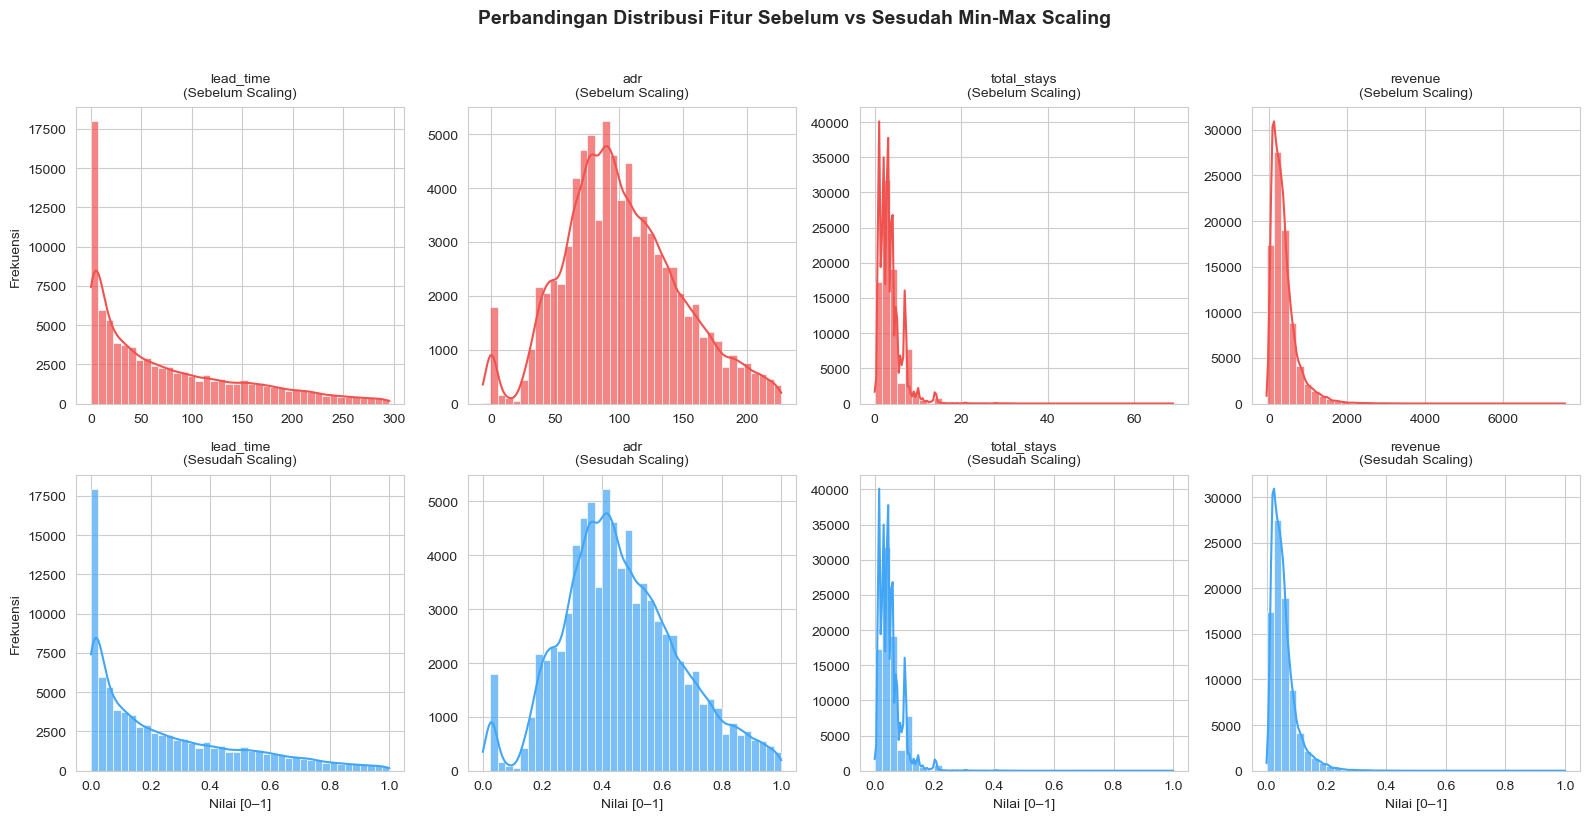

In [19]:
sns.set_style('whitegrid')

cols_viz = ['lead_time', 'adr', 'total_stays', 'revenue']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

df_before = df[cols_viz]
df_after  = df_scaled[cols_viz]

for i, col in enumerate(cols_viz):
    # Before
    sns.histplot(df_before[col], bins=40, kde=True, ax=axes[0][i],
                 color='#EF5350', alpha=0.7)
    axes[0][i].set_title(f'{col}\n(Sebelum Scaling)', fontsize=10, pad=8)
    axes[0][i].set_xlabel('')
    axes[0][i].set_ylabel('Frekuensi' if i == 0 else '')

    # After
    sns.histplot(df_after[col], bins=40, kde=True, ax=axes[1][i],
                 color='#42A5F5', alpha=0.7)
    axes[1][i].set_title(f'{col}\n(Sesudah Scaling)', fontsize=10, pad=8)
    axes[1][i].set_xlabel('Nilai [0–1]' if i >= 0 else '')
    axes[1][i].set_ylabel('Frekuensi' if i == 0 else '')

plt.suptitle('Perbandingan Distribusi Fitur Sebelum vs Sesudah Min-Max Scaling',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()